# Regresión Logistica

## Procesamiento de datos

Para la exploración de datos vamos a hacer uso de la base de datos MNIST, el cual posee imagenes de los digitos manuscritos (del 0 al 9). Lo que se pretende hacer es entrenar un clasificador que a partir de una imagen de la base de datos, prediga si el dígito es par o impar.

El primer paso es la carga de la base de datos utilizando *tensorflow.keras.datasets.mnist.load_data* e importando MNIST, luego mediante la función *load_data()* procedemos a retornar una tupla de Numpy en la cual contiene los datos de entrenamiento y de testeo. En el codigo *x_train* y *x_test* representan la imagen, mientras que *y_train* e *y_test* representan los digitos correspondientes a las imagenes.

Luego utilizando *imshow* se representaron 10 muestras aleatorias del conjunto de testeo, tanto imagen (*x_test*) como el número que lo representa *y_test*.

Como último paso de la exploración de datos, implementamos la etiqueta tanto para entrenamiento y testeo donde pueda predecir si el digito es par o impar, si es par retorna un cero y si es impar retorna un 1. El operador modulo % lo que hace es darme el resto de la división que se genera.




In [12]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import mnist

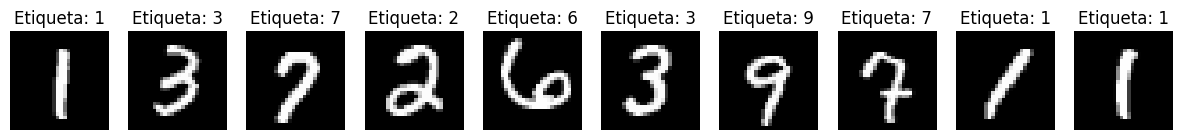

In [13]:
(x_train,y_train),(x_test,y_test) = mnist.load_data() #Tupla de datos perteneciente a mnist

random = np.random.choice(len(x_test), 10, replace = False) #Genero un vector de dim 10, con 10 indices diferentes en el rango de len(x_test)

#Gráfico de las imagenes de mnist
plt.figure(figsize=(15, 3))
for i, idx in enumerate(random):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_test[idx], cmap="gray")
    plt.title(f"Etiqueta: {y_test[idx]}")
    plt.axis("off")
plt.show()

# Etiquetas de par o impar (0 si es par, 1 si es impar)
y_train_bin = y_train % 2
y_test_bin = y_test % 2

## Preprocesamiento

Para la etapa de preprocesamiento, implemento la normalización desde una clase, en la que primero defino los atributos que voy a guardar, como la media, desviación estándar y las columnas con media distinta de cero, luego en la parte de entrenamiento en *fit*, calculo la media y la desviación estándar de cada feature (columna), luego en *transform* aplica la transformación de normalización a los features válidos definida como:

$$
 X' = \frac{X-μ}{σ}
$$


Luego en *fit_transform* se combinan ambos pasos, tanto los del entrenamiento como los de la transformación de los datos.

A los datos de entrenamiento y de testeo se los procede a normalizar mediante el modelo generado.  


In [14]:
class Normalizar:
  #Atributos
  def __init__(self):
    self.media = None #Guarda el vector de medias de cada feature(columna) del conjunto de entrenamiento
    self.desv_estand = None #Guarda la desviación estandar de cada feature
    self.valid_features = None  #Vector booleano que indica que columnas tienen varianza distinta a cero

  # Etapa de entrenamiento
  def fit(self,X):
    # Calcular media y desviación estándar por columna
    self.media = np.mean(X, axis=0) #Axis = 0 operacion por columna (si fuera por fila es Axis = 1)
    self.desv_estand = np.std(X, axis=0)
    self.valid_features = self.desv_estand > 0 # Guardar qué features tienen varianza distinta de cero

    self.media = self.media[self.valid_features]  #Solo mantener los features validos
    self.desv_estand = self.desv_estand[self.valid_features]

  def transform(self, X):
      X_valid = X[:, self.valid_features]   # Mantener solo features válidos
      return (X_valid - self.media) / self.desv_estand #Normalizar

  def fit_transform(self, X):
      self.fit(X)
      return self.transform(X)

In [15]:
Normalizador = Normalizar()
X_train_norm = Normalizador.fit_transform(x_train.astype(np.float32))
X_test_norm = Normalizador.transform(x_test.astype(np.float32))

## Analisis Teorico



### 1. Función Inversa de la Sigmoide σ⁻¹(p)

La función sigmoide está definida como:
$$σ(z) = \frac{1}{1 + e^{-z}}$$

Para encontrar la inversa, partimos de:
$$p = σ(z) = \frac{1}{1 + e^{-z}}$$

Despejando z:
$$p(1 + e^{-z}) = 1$$
$$p + pe^{-z} = 1$$
$$pe^{-z} = 1 - p$$
$$e^{-z} = \frac{1-p}{p}$$
$$-z = \ln\left(\frac{1-p}{p}\right)$$
$$z = \ln\left(\frac{p}{1-p}\right)$$

Por tanto, la función inversa es:
$$σ^{-1}(p) = \ln\left(\frac{p}{1-p}\right) = \text{logit}(p)$$

Esta función se conoce como **logit** y es válida para p ∈ (0,1). 

### 2. Derivada de la Función Sigmoide σ'(z)

Partiendo de:
$$σ(z) = \frac{1}{1 + e^{-z}} = (1 + e^{-z})^{-1}$$

Aplicando la regla de la cadena:
$$σ'(z) = -(1 + e^{-z})^{-2} \cdot (-e^{-z}) = \frac{e^{-z}}{(1 + e^{-z})^2}$$

Para expresarlo en función de p = σ(z), notemos que:
- $σ(z) = \frac{1}{1 + e^{-z}} = p$
- $1 - σ(z) = \frac{e^{-z}}{1 + e^{-z}} = 1 - p$

Por tanto:
$$σ'(z) = \frac{e^{-z}}{(1 + e^{-z})^2} = \frac{1}{1 + e^{-z}} \cdot \frac{e^{-z}}{1 + e^{-z}} = σ(z) \cdot (1 - σ(z))$$

### 3. Función de Costo y su Gradiente

El objetivo de la función costo es medir el ''error'' entre la predicción del modelo y el valor real. Para la regresión logística binaria, la predicción es: 
$$ \hat{y} = \sigma (w^Tx +b)$$
Por lo que para este caso usamos la función *Log Loss*:

$$J = -\frac{1}{n}\sum_{i=1}^{n} [Y_{i} \log(σ(w^t X_i + b)) + (1-Y_{i}) \log(1-σ(w^t X_i + b))]$$

El gradiente nos indica la dirección de máximo crecimiento de la función costo. Como el objetivo es encontrar los valores de peso **w** y el sesgo **b** que minimizan esta función de costo, entonces el gradiente es sobre esos parametros. 

En principio calculo $\Delta L(w,b)_w$:

$$\ell(X_i,Y_i) = -[Y_i\log(\hat{y}_i)] + (1-Y_i)\log(1-\hat{y}_i) $$

Derivo con respecto a $w$, aplicando regla de la cadena:

$$ \frac{\partial\ell}{\partial w} = -[\frac{Y_i}{\hat{y}_i}\cdot\frac{\partial\hat{y}_i}{\partial w}-\frac{1-Y_i}{1-\hat{y}_i}\cdot\frac{\partial\hat{y}_i}{\partial w}]$$

Luego:

$$ \frac{\partial\hat{y}_i}{\partial w} = \frac{\partial\hat{y}_i}{\partial z_i}\cdot\frac{\partial z_i}{\partial w}= \hat{y}_i(1-\hat{y}_i)\cdot X_i  $$

Por lo tanto el gradiente $\Delta L(w,b)_w$:

$$\frac{\partial\ell}{\partial w} = -(\frac{Y_i-\hat{y}_i}{\hat{y}_i(1-\hat{y}_i)})\cdot\hat{y}_i(1-\hat{y}_i)X_i = -(Y_i - \hat{y}_i)X_i  $$

Luego derivamos con respecto a $b$:

$$
\begin{align*}
\frac{\partial\ell}{\partial b} &= \frac{\partial\ell_i}{\partial\hat{y}_i}\cdot\frac{\partial\hat{y}_i}{\partial z_i}\cdot\frac{\partial z_i}{\partial b} \\
&= -\left(\frac{Y_i}{\hat{y}_i} - \frac{1 - Y_i}{1 - \hat{y}_i}\right) \cdot \hat{y}_i(1 - \hat{y}_i) \cdot 1 \\
&= \hat{y}_i - Y_i
\end{align*}
$$

Por lo tanto se halló el gradiente en función de $w$ y en función de $b$, estos nos ayudaran para minimizar el error de la predicción.

## Regresión logística binaria

Para este apartado se tuvo que implementar una regresión logistica binaria utilizando gradiente descendiente. La regresión logistica binaria es un algoritmo de Machine Learning utilizado para problemas de clasificación binaria. Su objetivo es predecir la probabilidad de una observación pertenezca a una de dos clases posibles.

En la función *fit* se inicializaron tanto el vector de caracteristicas como el vector de pesos (w + bias), luego se implemento lo que es el gradiente descendiente, el cual minimiza la función costo, la cual nos dice que tan ''bien'' o ''mal'' esta prediciendo nuestro modelo. 

Luego *predict_proba* que se refiere a la etapa de testeo soft, es un algoritmo que predice las probabilidades estimadas. No decide directamente la clase, solo da la confianza del modelo.

Luego *predict* es la etapa de testeo hard, en la cual es una estimación del valor predicto. La cual se la suele medir a partir de la predicción soft mediante un umbral. 

*Acurrancy* mide que fracción de las predicciones son correctas.

Para problemas de clasificación binaria, usamos la función de
*Cross Entropy* se refiere a la entropia cruzada, esta se utiliza para reducir el bias.

Finalmente podemos ver que a medida que aumentan  las iteraciones, el modelo ajusta los parametros para mejorar la predicción, esto resulta en que el riesgo empirico va disminuyendo hasta que converge en un valor, esto significa que el modelo ya encontro un conjunto de parametros óptimos, las mejoras producidas no van a ser significantes a partir de ahi.



In [16]:
class RegresionLogistica:
    def __init__(self, lr, max_iter):
        self.lr = lr #Learning rate
        self.max_iter = max_iter #max_iter son la cantidad de iteraciones del entrenamiento
        self.theta = None #Vector de parametros que se aprenderan durante el entrenamiento
    
    #Etapa de entrenamiento 
    def fit(self, X, y):
        X = np.c_[np.ones(X.shape[0]), X] #Inializo el vector de caracteristicas 
        self.theta = np.zeros(X.shape[1]) #Inicializo el vector de pesos w + bias
        self.loss_history = []
        #Aplico el método del gradiente descendiente
        for _ in range(self.max_iter): 
            z = X @ self.theta 
            sigmoide = 1 / (1 + np.exp(-np.clip(z, -500, 500))) #Clip limita valores      
            # Calcular gradiente y actualizar
            grad = X.T @ (sigmoide - y) / len(y)  #Gradiente de la función costo grad.J(theta) = (1/m)X^t.(\hat(y)-y)  
            self.theta -= self.lr * grad #Theta_{t+1} Se actualizan los pesos en direccion opuesta al gradiente 
            eps = 1e-15 
            loss = -np.mean(y * np.log(sigmoide + eps) + (1-y) * np.log(1 - sigmoide + eps))
            self.loss_history.append(loss) #Se almacena el valor de la perdida en cada iteración
            
    #Etapa de testeo soft:
    def predict_proba(self, X): 
        X = np.c_[np.ones(X.shape[0]), X] #Inicializo mi vector de caracteristicas
        z = X @ self.theta
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    #Etapa de testeo hard: 
    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int) 
    
    #Computar el Accuracy (precisión)
    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)
    
    #Computar la Cross-Entropy, 
    def cross_entropy(self, X, y): 
        y_pred = self.predict_proba(X)
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y*np.log(y_pred) + (1-y)*np.log(1-y_pred))



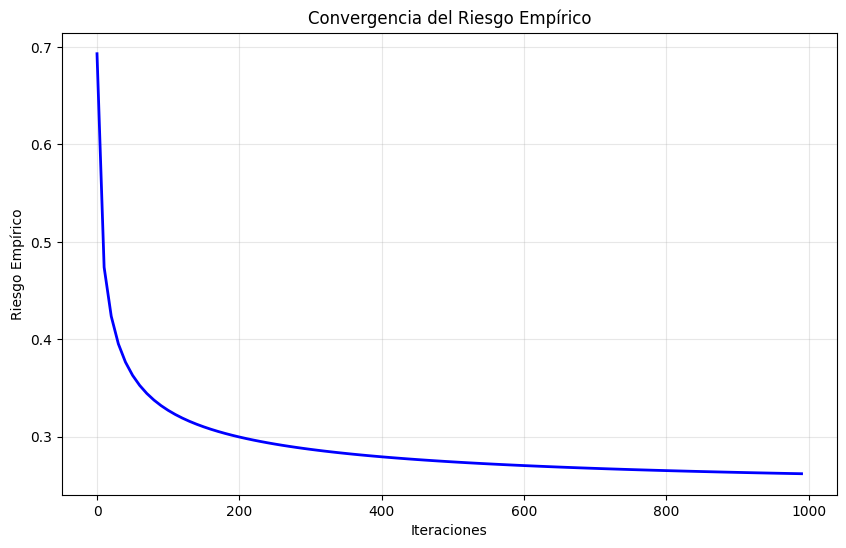

Accuracy train: 0.8958166666666667
Cross-Entropy train: 0.26202108868548385
Accuracy test: 0.8958
Cross-Entropy test: 0.2634927482179199


In [17]:
modelo = RegresionLogistica(lr=0.1, max_iter=100)
modelo.fit(X_train_norm, y_train_bin)

# Graficar convergencia del riesgo empírico
plt.figure(figsize=(10, 6))
iterations = range(0, len(modelo.loss_history) * 10, 10)
plt.plot(iterations, modelo.loss_history, 'b-', linewidth=2)
plt.title('Convergencia del Riesgo Empírico')
plt.xlabel('Iteraciones')
plt.ylabel('Riesgo Empírico')
plt.grid(True, alpha=0.3)
plt.show()

print("Accuracy train:", modelo.accuracy(X_train_norm, y_train_bin))
print("Cross-Entropy train:", modelo.cross_entropy(X_train_norm, y_train_bin))
print("Accuracy test:", modelo.accuracy(X_test_norm, y_test_bin))
print("Cross-Entropy test:", modelo.cross_entropy(X_test_norm, y_test_bin))



## Curvas ROC

La curva ROC es una herramienta visual que nos permite evaluar el rendimiento de un modelo a través de todos los posibles umbrales. Y se construye a partir de dos métricas, el eje Y sera el *Recall* que se enfoca en la capacidad del modelo para capturar todos los casos de la clase de interes, es crucial cuando el costo de un falso negativo es alto. Y el eje X es la tasa de falsos positivos. Esta curva la comparamos con la recta $y = x$, que representa un clasificador aleatorio, un modelo por debajo de esta línea es peor que el azar. Mientras que a medida que nos acercamos al punto (0,1) este representa un clasificador perfecto. Como podemos ver en nuestra curva podemos decir que nuestro modelo se comporta aproximadamente como un clasificador perfecto, dada la gran proximidad al punto (0,1).

 Los puntos del gráfico a tener en cuenta son el origen, que este corresponde a un umbral muy alto, el modelo no puede predecir ningun positivo, por lo qu eno tiene ni verdaderos positivos ni falsos positivos. Luego esta el Punto (1,1), que corresponde a un umbral muy bajo, el modelo predice todo como positivo, y captura todos los positivos reales como también los negativos. 

Después el area debajo de la curva ROC, resume el rendimiento del modelo en todos los umbrales, como tenemos un AUC de aprox 0.9 podemos decir que se aproxima a un clasificador perfecto como anteriormente se dijo. La AUC formalmente representa la probabilidad de que el modelo asigne una puntuación más alta a una instancia positiva elegida al azar que a una instancia negativa elegida al azar. 

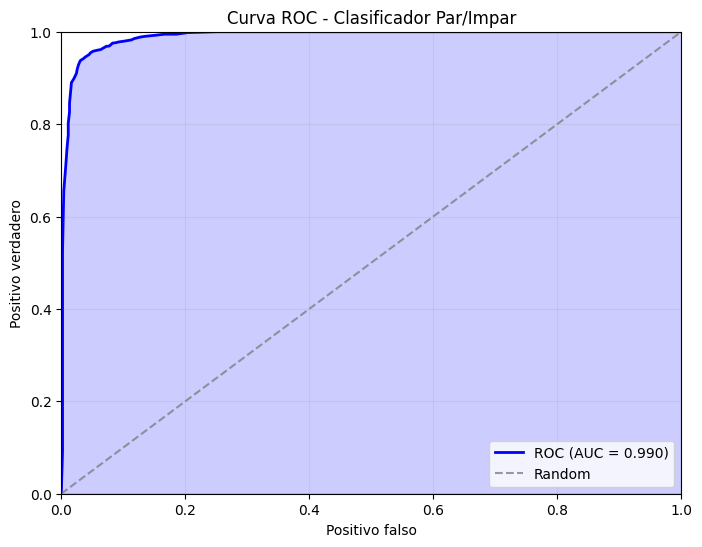

AUC = 0.990


In [18]:
def roc_curva(y_true, y_proba):
    
    y_true = np.array(y_true) #Etiquetas verdaderas
    y_proba = np.array(y_proba).flatten() #Probabilidades 
    
    thresholds = np.linspace(0, 1, 50)
    P = np.sum(y_true == 1) #cant. de positivos
    N = np.sum(y_true == 0) #cant. de negativos
    
    #Vectores para "guardar" los resultados de P y N
    tpr = np.zeros(len(thresholds)) 
    fpr = np.zeros(len(thresholds))
    
    for i, thr in enumerate(thresholds):
        y_pred = (y_proba >= thr) #thr es mi umbral de decisión que decidi que fuera 0.5
        TP = np.sum(y_pred & (y_true == 1)) #Calculo los verdaderos positivos
        FP = np.sum(y_pred & (y_true == 0)) #Calculo los falsos positivos
        
        tpr[i] = TP / P if P > 0 else 0  #verdaderos positivos/cant de positivos
        fpr[i] = FP / N if N > 0 else 0  #falsos positivos/negativos
    
    return fpr, tpr

#Probabilidad del modelo para los datos test
y_proba_test = modelo.predict_proba(X_test_norm).flatten()

#Puntos de la curva 
fpr, tpr = roc_curva(y_test, y_proba_test)

# Calcular Area bajo la curva (AUC)
roc_auc = -np.trapezoid(tpr, fpr) #trapezoid aproxima el área bajo esos puntos

# Graficar ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", linewidth=2, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", alpha=0.8, label="Random")
plt.fill_between(fpr, tpr, alpha=0.2, color="blue")

plt.xlabel("Positivo falso")
plt.ylabel("Positivo verdadero")
plt.title("Curva ROC - Clasificador Par/Impar")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

print(f"AUC = {roc_auc:.3f}")
